# NGS variant calling workflow

<div style="background-color: PaleTurquoise; padding: 10px;">
    
This notebook contains a simple SNP calling workflow.

Please run and explore this workflow.

Areas with questions about QC are highlighted in yellow

</div>

## Case

Two exome sequencing samples of a T-Cell Acute Lymphoblastic Leukemia patient. 

One sample (`TLE66_T`) is of tumor, one healthy control sample  (`TLE66_N`)

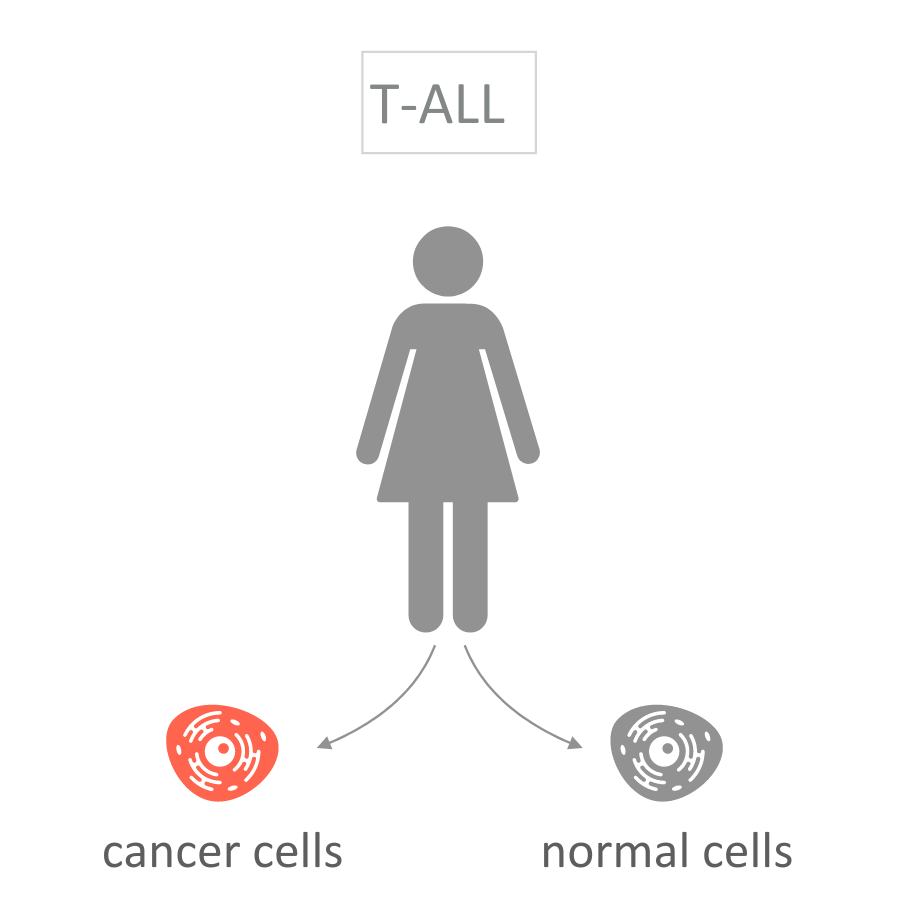

Goal: process the raw fastq, call & annotate SNPs.

We want to ultimately find interesting variants that may be causal to the T-ALL.

## Preparation

In [1]:
echo $VSC_DATA

/data/leuven/381/vsc38182
/vsc-hard-mounts/leuven-data/381/vsc38182/r1085920_Jose_Santos_Costa/010_manual_snpcall


The cleanest way to work with notebooks is to first create a folder on your server (VSC). For example:

    mkdir $VSC_DATA/variant_calling_manual

- You can do this in the jupyter interface
- Upload your notebook to this folder
- Navigate to this folder from jupyter
- Open the notebook

This ensures you are always working from the correct location. If you did not do this, please shutdown this notebook and do this.

If you do not do this, you are in the wrong folder upon a notebook crash, or when you forget to cd into your workfolder.

In [2]:
mkdir -p $VSC_DATA/variant_calling_manual
mv manual_snp_calling_workflow.ipynb $VSC_DATA/variant_calling_manual
cd $VSC_DATA/variant_calling_manual
touch README.md
ls

fastqc_output			   TLE66_N.bam	    TLE66_T.bam.bai
manual_snp_calling_workflow.ipynb  TLE66_N.bam.bai  TLE66_T.fastq
raw_snps.vcf			   TLE66_N.fastq
README.md			   TLE66_T.bam


In [3]:
# make sure we add our conda environment to the path
# there are also a number of command line tools installed
# You need to do this every time you need to use our conda env.

export PATH=/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/:$PATH

In [4]:
# ensure we are using the correct environment - test with bwa

which bwa

/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/bwa


In [5]:
# create a scratch folder! - Important to check you are working in the correct scratch folder for subsequent workœ
# Make sure you use absolute paths as much as possible - relative paths can give unexpected results.
# image running (`mkdir variant_calling_manual ; cd variant_calling_manual`) twice in a row.

mkdir -p $VSC_SCRATCH/variant_calling_manual
cd $VSC_SCRATCH/variant_calling_manual
pwd
ls

/scratch/leuven/381/vsc38182/variant_calling_manual
annotated_snps.vcf  README.md		 TLE66_N.bam.bai      TLE66_T.bam
clean_snps.vcf	    snpEff_genes.txt	 TLE66_N.fastq	      TLE66_T.bam.bai
fastqc_output	    snpEff_summary.html  TLE66_N_fastqc.html  TLE66_T.fastq
raw_snps.vcf	    TLE66_N.bam		 TLE66_N_fastqc.zip


In [6]:
# We will be using the genome sequence & index a few times - 
# So I'll use an environment variable

# Note - we are definitely using hg19 for this course.

# To keep memory requirements in check we're using a truncated database with just chromosome 9
DB=/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa

In [7]:
ls -lh $DB

-rw-rw-r--+ 1 vsc30690 lp_edu_large_omics 135M Jan 24  2014 /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


<div style="background-color: khaki; padding: 10px;">

## Prepare

* What are the version numbers of all tools used in this notebook. Get it from the tools!
 
</div>

In [8]:
# Create a symlink to VSC_SCRATCH from $VSC_DATA -
# so that you can inspect your data using the jupyter file browser
ln -sf $VSC_SCRATCH $VSC_DATA/scratch 

In [9]:
ln -sf /staging/leuven/stg_00079/teaching/data_manual_snpcall/*.fastq .
ls -l

total 40128
-rw-r----- 1 vsc38182 vsc38182  1775439 Mar  2 15:33 annotated_snps.vcf
-rw-r----- 1 vsc38182 vsc38182   567832 Mar  2 14:58 clean_snps.vcf
drwxr-x--- 2 vsc38182 vsc38182     4096 Mar  2 14:35 fastqc_output
-rw-r----- 1 vsc38182 vsc38182   982232 Mar  2 14:36 raw_snps.vcf
-rw-r----- 1 vsc38182 vsc38182        0 Feb 26 14:54 README.md
-rw-r----- 1 vsc38182 vsc38182    43281 Mar  2 15:33 snpEff_genes.txt
-rw-r----- 1 vsc38182 vsc38182   230498 Mar  2 15:33 snpEff_summary.html
-rw-r----- 1 vsc38182 vsc38182 36321020 Mar  2 14:36 TLE66_N.bam
-rw-r----- 1 vsc38182 vsc38182    80208 Mar  2 14:36 TLE66_N.bam.bai
lrwxrwxrwx 1 vsc38182 vsc38182       68 Mar  2 16:34 TLE66_N.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_N.fastq
-rw-r----- 1 vsc38182 vsc38182   642489 Feb 28 15:59 TLE66_N_fastqc.html
-rw-r----- 1 vsc38182 vsc38182   339372 Feb 28 15:59 TLE66_N_fastqc.zip
-rw-r----- 1 vsc38182 vsc38182        0 Mar  2 15:56 TLE66_T.bam
-rw-r----- 1 vsc38182 vsc3

The `sha256` checksums of these files are supposed to be:

    5ad4bb2f5bd5f6e430b7ab2fff0a164255d4e608363104a75142b6c5a032ddf9  TLE66_N.fastq
    cd9d41d1c0b59a4819fa58007ef796c543b1a7346cb11cceb71ad02d9e2b2cfe  TLE66_T.fastq


<div style="background-color: khaki; padding: 10px;">

## Raw data Quality Control

* Do the checksums match?
* Do the raw files look like fastq?
* Do they have a reasonable number of reads?
 
</div>

In [10]:
#check if the checksums match
md5sum TLE*
#Output is:
##8cb3b02a883409dbb89977442a7ed32a  TLE66_N.fastq
##4b1ef74e568cc9e6d3c41cff0f06d785  TLE66_T.fastq
#So they don't match

49059498115a66dd3272c2c1044f4cb3  TLE66_N.bam
02c69376bea9ddc00eb2181613cc1610  TLE66_N.bam.bai
8cb3b02a883409dbb89977442a7ed32a  TLE66_N.fastq
1511e8bffc4142b64af9d9dd22a620ad  TLE66_N_fastqc.html
c8297c1771433f6c092c77a74528820d  TLE66_N_fastqc.zip
d41d8cd98f00b204e9800998ecf8427e  TLE66_T.bam
005d2a6454ddaa81f42f23747224da6a  TLE66_T.bam.bai
4b1ef74e568cc9e6d3c41cff0f06d785  TLE66_T.fastq


In [12]:
#Check if the raw files look like fastq
head TLE66_N.fastq
head TLE66_T.fastq
#Its a fastaq file because it has 4 lines format where each line corresponds to something:
 # first line: header
 # second line: sequence
 # third line: separator
 # fourth line: quality score

@1121358
TGAATCTGGGAGGCGGAGGTTGCAGTGAGAGTGAGGCGAGATCTCGCCATTGCACTCCAGCCGGGGTGACAAGAG
+
<D<?><DIBB??BF;@;AB@CHG<A?F<@>@;F>>6?8??@@BD,;FF=?DIBD?F;EDAGE8BBC9G?FEBB>@
@1121358
AGCCTCAAACTCCTGGGCTCAAGGGATCCTCACTTCTTGACCTCCCAAAGCGTCATAGGCTTAAGGCACTACAGC
+
A:EFFACACFE?FCG5CG9>C@@B@<@=@FACFEE<F9C>E6FAC+7>:AF=B=A?>B;CG>:<A:<=<B;:0=;
@FCB06B3ABXX:8:1105:13917:3018
TCCCTTGAGCCCAGGAGTTTGAGGCTGCATTGAGCTATGATCATTCCGCTGCACTCCAGCCTGAGTGACAGAGCA
@8884837
CCTATGACGCTTTGGGAGGTCAAGAAGTGAGGATCCCTTGAGCCCAGGAGTTTGAGGCTGCATTGAGCTATGATC
+
=AB?AHBF>GGEEIFFBFFBFDEDBEGAICDGBDDHHHEIBEHHFEEFBFBDFIBGGHFIGCCEB?@GG@AH>A?
@FCD0CAEABXX:4:2104:17216:94349
TGACGCTTTGGGAGGTCAAGAAGTGAGGATCCCTTGAGCCCAGGAGTTTGAGGCTGCATTGAGCTATGATCATTC
+
<C<E;EEDDIID=CDABDBBABCBEAEDAC@GGFDF@AFE<CBB@CBF3H?C;>GEC?@DB/@B9,:@:7>A@7?
@641542
CTCTGGAGGATCCCTTGAGCCCAGGAGTTTGAGGCTGCATTGAGCTATGATCATTCTGCTGCACTCCAGCCTGAG


In [12]:
# you can get help using
fastqc --help


            FastQC - A high throughput sequence QC analysis tool

SYNOPSIS

	fastqc seqfile1 seqfile2 .. seqfileN

    fastqc [-o output dir] [--(no)extract] [-f fastq|bam|sam] 
           [-c contaminant file] seqfile1 .. seqfileN

DESCRIPTION

    FastQC reads a set of sequence files and produces from each one a quality
    control report consisting of a number of different modules, each one of 
    which will help to identify a different potential type of problem in your
    data.
    
    If no files to process are specified on the command line then the program
    will start as an interactive graphical application.  If files are provided
    on the command line then the program will run with no user interaction
    required.  In this mode it is suitable for inclusion into a standardised
    analysis pipeline.
    
    The options for the program as as follows:
    
    -h --help       Print this help file and exit
    
    -v --version    Print the version of the program and exit

In [13]:
# Run fastqc - could take a minute or two
mkdir -p fastqc_output
fastqc *.fastq -o fastqc_output

null
null
Started analysis of TLE66_N.fastq
Approx 5% complete for TLE66_N.fastq
Approx 10% complete for TLE66_N.fastq
Approx 15% complete for TLE66_N.fastq
Approx 20% complete for TLE66_N.fastq
Approx 25% complete for TLE66_N.fastq
Approx 30% complete for TLE66_N.fastq
Approx 35% complete for TLE66_N.fastq
Approx 40% complete for TLE66_N.fastq
Approx 45% complete for TLE66_N.fastq
Approx 50% complete for TLE66_N.fastq
Approx 55% complete for TLE66_N.fastq
Approx 60% complete for TLE66_N.fastq
Approx 65% complete for TLE66_N.fastq
Approx 70% complete for TLE66_N.fastq
Approx 75% complete for TLE66_N.fastq
Approx 80% complete for TLE66_N.fastq
Approx 85% complete for TLE66_N.fastq
Approx 90% complete for TLE66_N.fastq
Approx 95% complete for TLE66_N.fastq
Analysis complete for TLE66_N.fastq
Started analysis of TLE66_T.fastq
Approx 5% complete for TLE66_T.fastq
Approx 10% complete for TLE66_T.fastq
Approx 15% complete for TLE66_T.fastq
Approx 20% complete for TLE66_T.fastq
Approx 25% com

## Check if the files have reasonable number of reads
Both samples have very low read counts for whole-exome sequencing (TLE66_N: 540,624; TLE66_T: 477,888), far below the tens of millions normally required, so they do not have a reasonable number of reads.


Back in your jupyter browser you can see the html & zip outputs

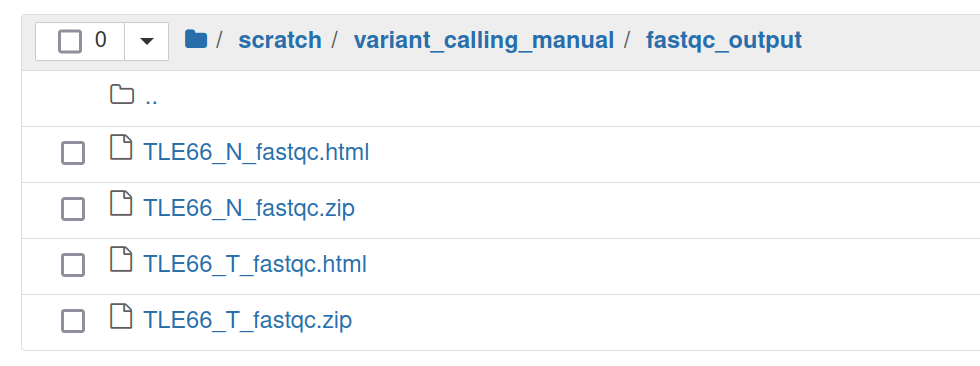


<div style="background-color: khaki; padding: 10px;">

## Fastq data Quality Control

* Is the quality ok?
* How is the quality score encoded? Do you need to take this into account?
 
</div>

### Is the quality good?
* Answer: Yes, the quality is good. The FastQC per-base sequence quality plots show that the median quality stays high across most of the read, with only a slight expected drop at the end, and no reads were flagged as poor quality.

### Question: How is the quality score encoded and do we need to take it into account?

The quality scores are encoded using **Sanger / Illumina 1.9 (Phred+33)**, where each ASCII character represents a Phred score:

\[
Q = -10 \cdot \log_{10}(P)
\]

with \(P\) the probability of a base being wrong. Yes, we need to take it into account, because it reflects the confidence in each base; low-quality bases may need trimming or filtering before analysis.of 0.01%.  

## Align the reads

We will be using `bwa mem`. Get help by running without arguments

In [14]:
bwa mem || true


Usage: bwa mem [options] <idxbase> <in1.fq> [in2.fq]

Algorithm options:

       -t INT        number of threads [1]
       -k INT        minimum seed length [19]
       -w INT        band width for banded alignment [100]
       -d INT        off-diagonal X-dropoff [100]
       -r FLOAT      look for internal seeds inside a seed longer than {-k} * FLOAT [1.5]
       -y INT        seed occurrence for the 3rd round seeding [20]
       -c INT        skip seeds with more than INT occurrences [500]
       -D FLOAT      drop chains shorter than FLOAT fraction of the longest overlapping chain [0.50]
       -W INT        discard a chain if seeded bases shorter than INT [0]
       -m INT        perform at most INT rounds of mate rescues for each read [50]
       -S            skip mate rescue
       -P            skip pairing; mate rescue performed unless -S also in use

Scoring options:

       -A INT        score for a sequence match, which scales options -TdBOELU unless overridden [1]
     

In [15]:
echo ${DB}

/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


In [16]:
bwa mem ${DB} TLE66_N.fastq | samtools sort -o TLE66_N.bam -

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 133334 sequences (10000050 bp)...
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 2.893 CPU sec, 2.967 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.274 CPU sec, 3.397 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.411 CPU sec, 3.464 real sec
[M::process] read 7288 sequences (546600 bp)...
[M::mem_process_seqs] Processed 133334 reads in 4.191 CPU sec, 4.243 real sec
[M::mem_process_seqs] Processed 7288 reads in 0.258 CPU sec, 0.300 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.fastq
[main] Real time: 15.439 sec; CPU: 14.235 sec


In [17]:
bwa mem ${DB} TLE66_T.fastq | samtools sort - > TLE66_T.bam

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 133334 sequences (10000050 bp)...
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 2.998 CPU sec, 3.012 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.375 CPU sec, 3.426 real sec
[M::process] read 77886 sequences (5841450 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.471 CPU sec, 3.522 real sec
[M::mem_process_seqs] Processed 77886 reads in 2.725 CPU sec, 2.777 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_T.fastq
[main] Real time: 12.928 sec; CPU: 12.730 sec


In [18]:
# create indici
samtools index TLE66_N.bam
samtools index TLE66_T.bam

In [19]:
pwd
ls -l

/scratch/leuven/381/vsc38182/variant_calling_manual
total 71796
-rw-r----- 1 vsc38182 vsc38182  1775439 Mar  2 15:33 annotated_snps.vcf
-rw-r----- 1 vsc38182 vsc38182   567832 Mar  2 14:58 clean_snps.vcf
drwxr-x--- 2 vsc38182 vsc38182     4096 Mar  2 14:35 fastqc_output
-rw-r----- 1 vsc38182 vsc38182   982232 Mar  2 14:36 raw_snps.vcf
-rw-r----- 1 vsc38182 vsc38182        0 Feb 26 14:54 README.md
-rw-r----- 1 vsc38182 vsc38182    43281 Mar  2 15:33 snpEff_genes.txt
-rw-r----- 1 vsc38182 vsc38182   230498 Mar  2 15:33 snpEff_summary.html
-rw-r----- 1 vsc38182 vsc38182 36321020 Mar  2 16:35 TLE66_N.bam
-rw-r----- 1 vsc38182 vsc38182    80208 Mar  2 16:35 TLE66_N.bam.bai
lrwxrwxrwx 1 vsc38182 vsc38182       68 Mar  2 16:34 TLE66_N.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_N.fastq
-rw-r----- 1 vsc38182 vsc38182   642489 Feb 28 15:59 TLE66_N_fastqc.html
-rw-r----- 1 vsc38182 vsc38182   339372 Feb 28 15:59 TLE66_N_fastqc.zip
-rw-r----- 1 vsc38182 vsc38182 32427184

<div style="background-color: khaki; padding: 10px;">

## BAM  Quality control

* Did all tools finish without error?
* Is the header correct? (Use `samtools view -H`)
* Do the files look like BAM? (Use `samtools view ... | head`)
* To which chromosomes to the reads map? (Use `samtools idxstats`) What do you expect? 
* How many & what percentage of the reads map properly? (Use `samtools flagstat`)
* Download the bam & bai files to disk & visualize in [IGV](https://igv.org/app/). Copy/paste a screenshot.

</div>

### Is the header correct?

In [20]:
samtools view -H TLE66_N.bam 

@HD	VN:1.5	SO:coordinate
@SQ	SN:chr9	LN:138394717
@PG	ID:bwa	PN:bwa	VN:0.7.19-r1273	CL:bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.fastq
@PG	ID:samtools	PN:samtools	PP:bwa	VN:1.23	CL:samtools sort -o TLE66_N.bam -
@PG	ID:samtools.1	PN:samtools	PP:samtools	VN:1.23	CL:samtools view -H TLE66_N.bam


In [21]:
samtools view -H TLE66_T.bam

@HD	VN:1.5	SO:coordinate
@SQ	SN:chr9	LN:138394717
@PG	ID:bwa	PN:bwa	VN:0.7.19-r1273	CL:bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_T.fastq
@PG	ID:samtools	PN:samtools	PP:bwa	VN:1.23	CL:samtools sort -
@PG	ID:samtools.1	PN:samtools	PP:samtools	VN:1.23	CL:samtools view -H TLE66_T.bam


Yes, both headers are correct.  

- **FASTQ headers** follow standard Sanger/Illumina 1.9 format, with a unique read ID, sequence line, `+` separator, and quality string of the expected length (75 bp).  
- **BAM headers** show the correct sort order (`SO:coordinate`), the reference sequence name and length (`@SQ SN:chr9 LN:138394717`) matching the reference FASTA, and include program information for BWA and samtools.  

Together, they indicate that reads and reference metadata are consistent and properly formatted for downstream analysis.

### Do the files look like BAM?

In [22]:
samtools view TLE66_N.bam | head

FCB06B3ABXX:8:2108:12853:63847	16	chr9	150174	0	75M	*	0	0	TGGAGTGCAGTGGTGCGATCTCAGCTCACTGCAAGCTCCGCCTCCCGGGTTCACGCCATTCTCCTGCCTCAGCCT	GGDGI/HJHI2IG>F=C=>CBJ7HD@HCC<EDFHHC8E=<EDBEE?IIIDBIC@HGJDECFAGFEIFFBJHGBED	NM:i:0	MD:Z:75	AS:i:75	XS:i:75
3320565	16	chr9	243917	0	75M	*	0	0	GCTCATGCCTGCAATCCCAGCACTTTGGGAGGCCGAGGCGGGCAGATCACGAGGTCAGGAGATCGAGACCATCCT	FDBIAEIGGEHIFBCEEIHHIADCEDHHFFHHF?FGHG?HHGIFECBIB?EFGGAIGHEFEBB?EFEAFIBAEDC	NM:i:1	MD:Z:11T63	AS:i:70	XS:i:70
6131457	0	chr9	532265	6	6S62M7S	*	0	0	CGGACGGAGTTTCACTCTTGGTGCCCACGCTGGAGTGCAGTGGCACCATCTCGGCTCACCGCAACCTCCACCTCC	=:A?E>EADADDEDFFEFDIEBHGG<C>7EGI<>A<FBAA:G?CBFB=???:764:346)28?2<<;*829<?>;	NM:i:2	MD:Z:14T6G40	AS:i:52	XS:i:48
5427388	0	chr9	741463	33	19S43M13S	*	0	0	CTGCACTCTAGCTGGGACCACAGGCACACACCACCACACCTGGCTTTTTTTTTTTTTTTTTTTAGTTGGGGTCCC	=AEDBEEDEAEGFHCEBGGDFDBBGDGDFDFFDGGBGDGGGIFGFEEEEEEEEEEEEEEED@#############	NM:i:0	MD:Z:43	AS:i:43	XS:i:37	XA:Z:chr9,+78228023,7S52M16S,3;
8177811	16	chr9	4648431	0	75M	*	0	0	GGCTCACGCCTGTAATCCCA

samtools view TLE66_T.bam | head

### Question: Do the files look like BAM?

Yes. Running `samtools view | head` produces the first few alignments in **SAM format**, showing read IDs, reference positions, CIGAR strings, sequences, and quality strings. This confirms the file is a **valid BAM file**, because `samtools` can read it and output alignments without errors.

We can also use samtools quickcheck to check if the files are valid and complete without reading the whole file. If the commands below dont give rise to any error, then the BAM files are correctly formatted

In [40]:
samtools quickcheck -v TLE66_N.bam
samtools quickcheck -v TLE66_T.bam

### To which chromossome do the reads map?

We should expect that all the reads map to chr 9 since our fastq files only contain chr 9

In [24]:
samtools idxstats TLE66_N.bam

chr9	138394717	540563	0
*	0	0	98


In [25]:
samtools idxstats TLE66_T.bam

chr9	138394717	477793	0
*	0	0	125


Both BAM files show that **almost all reads map to chromosome 9**, which is the reference used for alignment:

- **TLE66_N.bam:** 540,563 reads mapped to chr9, 98 unmapped  
- **TLE66_T.bam:** 477,793 reads mapped to chr9, 125 unmapped  

A very small number of reads remain unmapped (`*`), but the vast majority correctly align to **chr9**, as expected.

### How many & what percentage of the reads map properly?

In [26]:
samtools flagstat TLE66_N.bam

540661 + 0 in total (QC-passed reads + QC-failed reads)
540624 + 0 primary
0 + 0 secondary
37 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
540563 + 0 mapped (99.98% : N/A)
540526 + 0 primary mapped (99.98% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [27]:
samtools flagstat TLE66_T.bam

477918 + 0 in total (QC-passed reads + QC-failed reads)
477888 + 0 primary
0 + 0 secondary
30 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
477793 + 0 mapped (99.97% : N/A)
477763 + 0 primary mapped (99.97% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


- **TLE66_N.bam:**  
  - Mapped reads: 540,563 out of 540,661  
  - Percentage mapped: **~99.98%**  
  - Properly paired: 0 (this is expected for **single-end reads**, not paired-end)

- **TLE66_T.bam:**  
  - Mapped reads: 477,793 out of 477,918  
  - Percentage mapped: **~99.97%**  
  - Properly paired: 0 (single-end reads)

**Interpretation:** Almost all reads are successfully aligned to the reference, which indicates a very good mapping rate. The "properly paired" field is zero because these are **single-end sequencing reads**, so paired-end statistics do not apply.

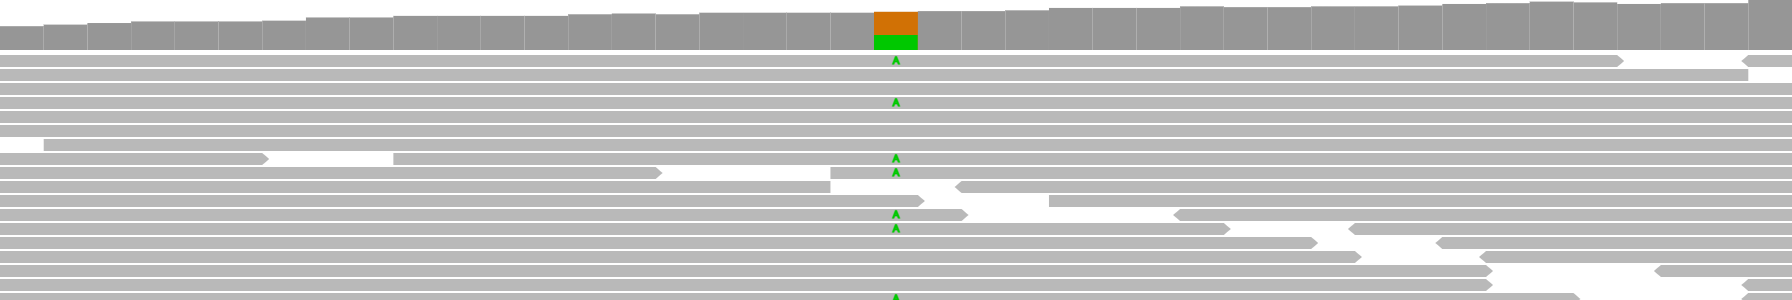

## SNP Calling

Using bcftools

In [28]:
#get help
bcftools mpileup || true


Usage: bcftools mpileup [options] in1.bam [in2.bam [...]]

Input options:
  -6, --illumina1.3+      Quality is in the Illumina-1.3+ encoding
  -A, --count-orphans     Include anomalous read pairs, with flag PAIRED but not PROPER_PAIR set
  -b, --bam-list FILE     List of input BAM filenames, one per line
  -B, --no-BAQ            Disable BAQ (per-Base Alignment Quality)
  -C, --adjust-MQ INT     Adjust mapping quality [0]
  -D, --full-BAQ          Apply BAQ everywhere, not just in problematic regions
  -d, --max-depth INT     Max raw per-file depth; avoids excessive memory usage [250]
  -E, --redo-BAQ          Recalculate BAQ on the fly, ignore existing BQs
  -f, --fasta-ref FILE    Faidx indexed reference sequence file
      --no-reference      Do not require fasta reference file
  -G, --read-groups FILE  Select or exclude read groups listed in the file
  -q, --min-MQ INT        Skip alignments with mapQ smaller than INT [0]
  -Q, --min-BQ INT        Skip bases with baseQ/BAQ smaller

In [29]:
bcftools mpileup -Ou -f ${DB} TLE66_N.bam TLE66_T.bam \
    | bcftools call -mv -Ov -o raw_snps.vcf

Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 2 samples in 2 input files
[mpileup] maximum number of reads per input file set to -d 250


In [31]:
head raw_snps.vcf

##fileformat=VCFv4.2
##FILTER=<ID=PASS,Description="All filters passed">
##bcftoolsVersion=1.23+htslib-1.23
##bcftoolsCommand=mpileup -Ou -f /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.bam TLE66_T.bam
##reference=file:///staging/leuven/stg_00079/teaching/hg38_9/chr9.fa
##contig=<ID=chr9,length=138394717>
##ALT=<ID=*,Description="Represents allele(s) other than observed.">
##INFO=<ID=INDEL,Number=0,Type=Flag,Description="Indicates that the variant is an INDEL.">
##INFO=<ID=IDV,Number=1,Type=Integer,Description="Maximum number of raw reads supporting an indel">
##INFO=<ID=IMF,Number=1,Type=Float,Description="Maximum fraction of raw reads supporting an indel">


In [32]:
grep  '^#' raw_snps.vcf | tail

##FORMAT=<ID=PL,Number=G,Type=Integer,Description="List of Phred-scaled genotype likelihoods">
##FORMAT=<ID=AD,Number=R,Type=Integer,Description="Allelic depths (high-quality bases)">
##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">
##INFO=<ID=AC,Number=A,Type=Integer,Description="Allele count in genotypes for each ALT allele, in the same order as listed">
##INFO=<ID=AN,Number=1,Type=Integer,Description="Total number of alleles in called genotypes">
##INFO=<ID=DP4,Number=4,Type=Integer,Description="Number of high-quality ref-forward , ref-reverse, alt-forward and alt-reverse bases">
##INFO=<ID=MQ,Number=1,Type=Integer,Description="Average mapping quality">
##bcftools_callVersion=1.23+htslib-1.23
##bcftools_callCommand=call -mv -Ov -o raw_snps.vcf; Date=Mon Mar  2 16:35:22 2026
#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	TLE66_N.bam	TLE66_T.bam


In [33]:
grep -v '^#' raw_snps.vcf | head -5

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082813	.	C	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082814	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	35641185	.	C	T	8.68025	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:35,3,0:0,1	./.:0,0,0:0,0


<div style="background-color: khaki; padding: 10px;">

## VCF/bcftools Quality control

* Did all tools finish without error?
* Is the file structure correct? (no lines, start, end, header, etc)
* Find a high quality SNP (awk, sort, excel, whatever you like). Discuss the criteria.
* Attempt to find a variants that are different between the two samples (awk?). Check in IGV, copy/paste screenshot.
* Visualize the above SNP in IGV, copy/paste a screenshot.

</div>

### Is the file structure correct?

Yes, the `raw_snps.vcf` file has a valid VCF structure:

- The file starts with **metadata lines** (`##`) that describe:
  - `fileformat=VCFv4.2` → correct VCF version  
  - Filters, reference genome, and contig information  
  - Info fields (`INDEL`, `IDV`, `IMF`) describing variant annotations
- There is a **contig line** specifying `chr9` and its length, matching the reference used for alignment
- The last metadata line (not shown here, but typically) starts with `#CHROM`, which defines the **columns for the variant table** (`CHROM, POS, ID, REF, ALT, QUAL, FILTER, INFO`)

**Conclusion:** The headers confirm that this VCF is structurally correct and ready for downstream variant analysis.


### High quality SNP

In [34]:
grep '^[^#]' raw_snps.vcf| sort -nr -k6,6  | head -1

chr9	137102481	.	T	G	486.063	.	DP=471;VDB=0.557019;SGB=-1.38629;RPBZ=1.16838;MQBZ=-1.73258;MQSBZ=0.956502;BQBZ=1.66605;SCBZ=0.147431;MQ0F=0.0636943;AC=4;AN=4;DP4=0,1,243,226;MQ=21	GT:PL:AD	1/1:255,255,0:1,232	1/1:255,255,0:0,236



This SNP is considered high-quality because:  

- It has a **very high QUAL score**, indicating strong confidence in the variant call.  
- **Read depth (DP=471)** is excellent, minimizing the chance of random errors.  
- **Strong support for the ALT allele** in both samples (`AD=232/236`) matches the homozygous genotype (1/1).  
- It is a **single-base change**, not an indel or complex variant.  
- Additional INFO fields (mapping quality, base quality metrics) show no evidence of sequencing or alignment artifacts.  

**Conclusion:** High-quality SNPs are typically selected based on **high QUAL**, **sufficient coverage**, **strong ALT allele support**, and **single-base REF/ALT changes**, all of which are satisfied here.are satisfied here.are satisfied here.

### Finding variants that are different between the two samples

In [35]:
grep '^[^#]' raw_snps.vcf | awk -F'\t' '{
  split($10,a,":"); split($11,b,":");
  if(a[1] != b[1]) print $1,$2,$4,$5,a[1],b[1]
}' | head


chr9 34082802 C T ./. 1/1
chr9 34082803 A G ./. 1/1
chr9 34082813 C G ./. 1/1
chr9 34082814 C T ./. 1/1
chr9 35641185 C T 1/1 ./.
chr9 35641189 G A 1/1 ./.
chr9 35641192 G T 1/1 ./.
chr9 35641215 C T 1/1 ./.
chr9 35641219 G A 1/1 ./.
chr9 89854448 C T ./. 1/1


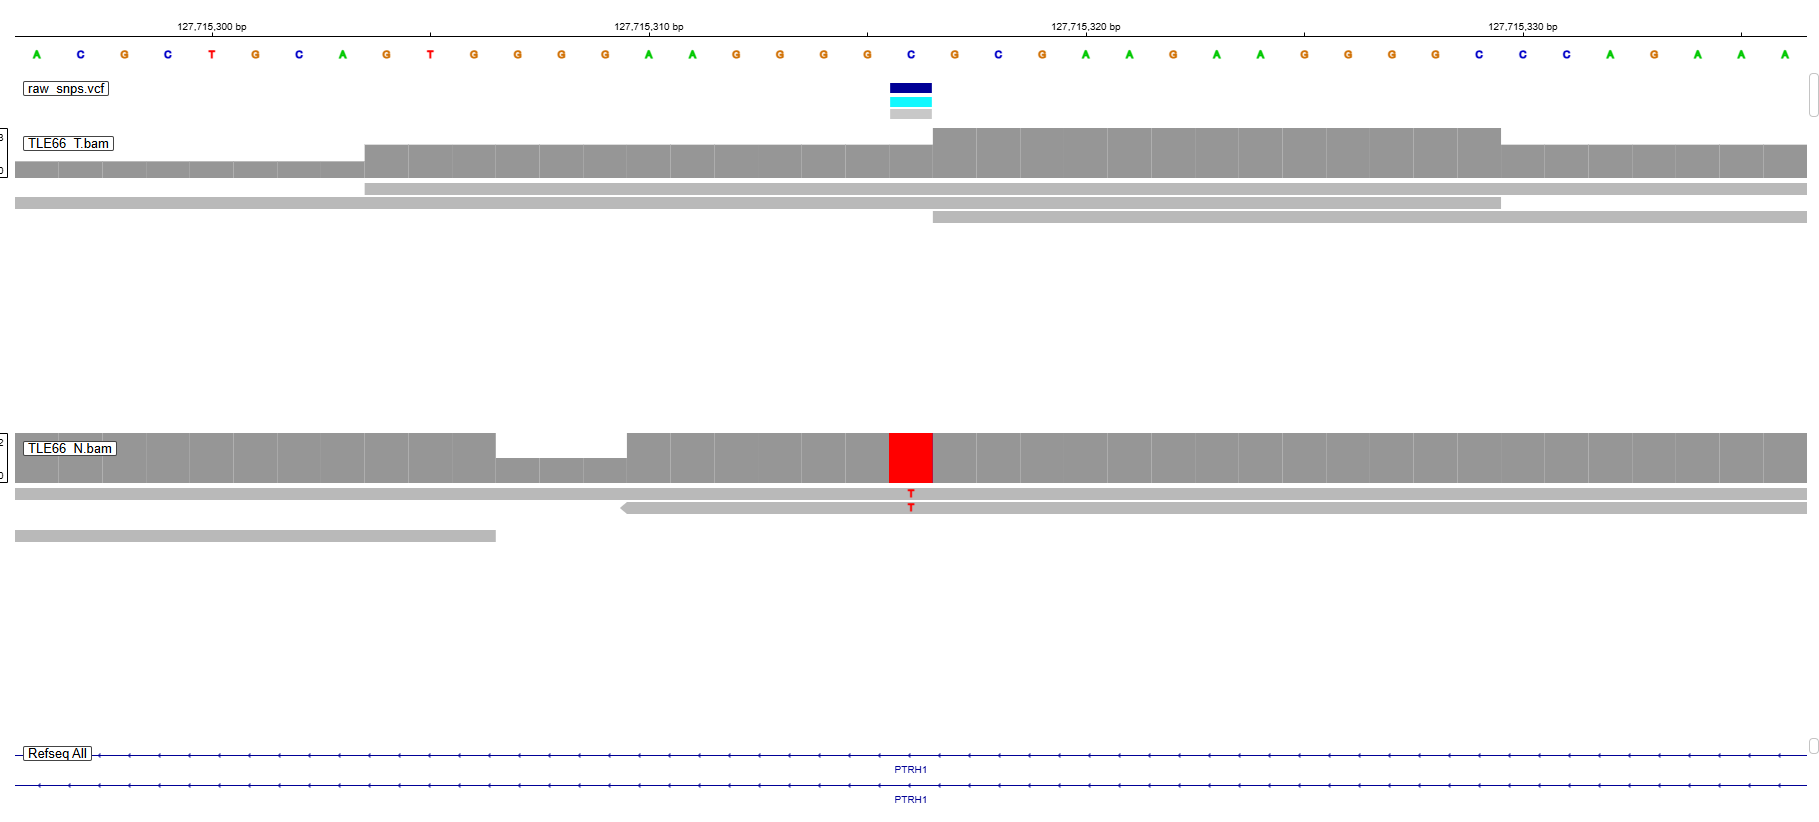

In [36]:
grep -v '#' raw_snps.vcf | head -2

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2


Not all SNPs are equaly convincing

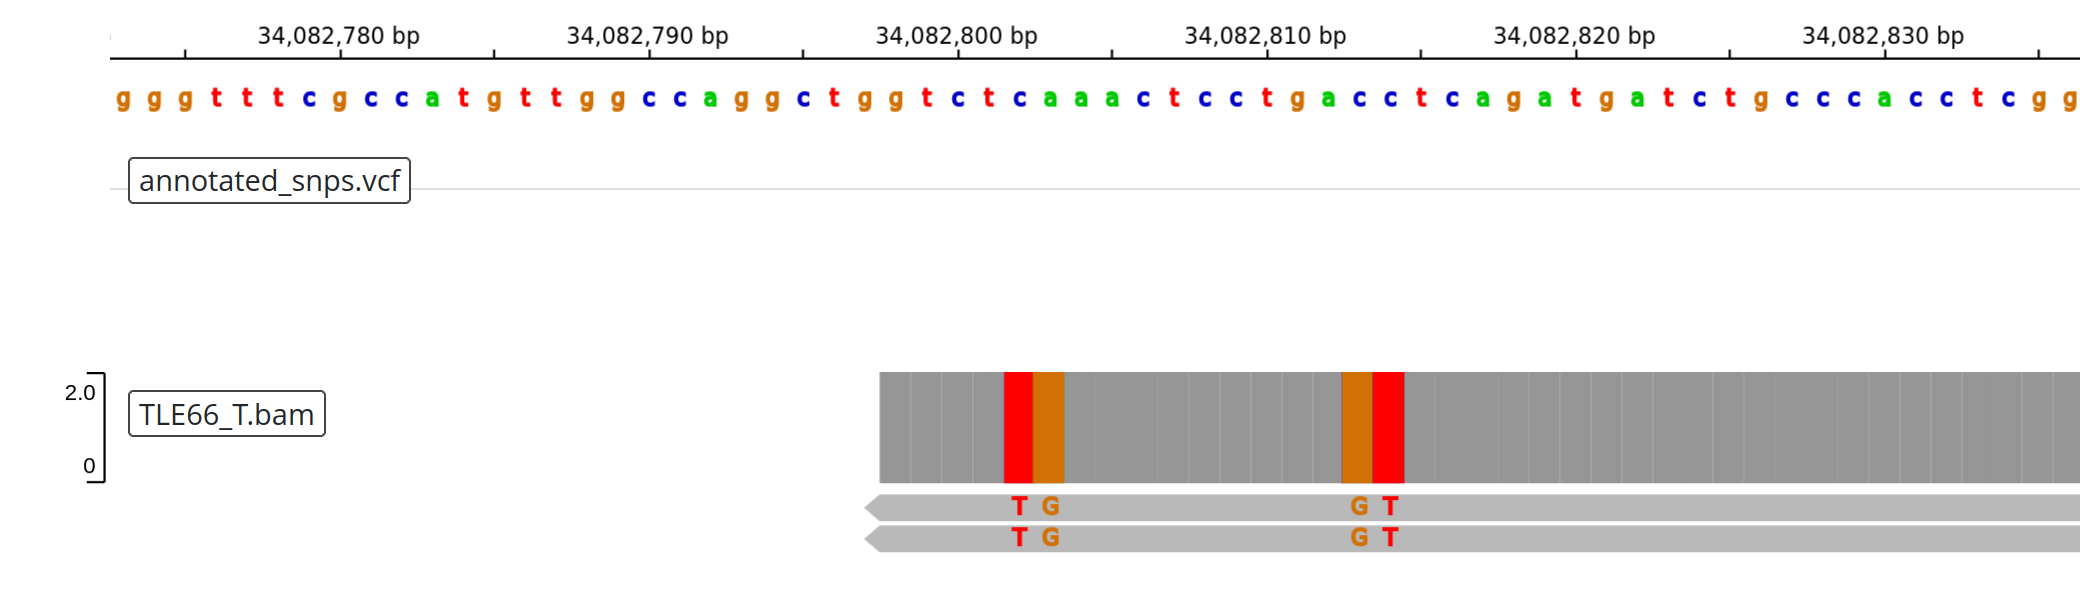

## SNP filtering & cleaning using `vt`

This is a VCF preprocessing pipeline that cleans up raw SNP calls before any downstream analysis. Each step fixes a specific class of problem:

* `vt decompose` splits multi-allelic variants (where multiple alternate alleles are listed on a single line) into separate biallelic records. Most tools downstream expect one variant per line, and PRS methods in particular are built around biallelic SNPs.
* `vt normalize -n -r $DB` left-aligns and normalizes indels against the reference genome. The same variant can be represented in multiple valid ways in VCF format — normalization ensures you have one canonical representation, which is critical when matching variants across datasets (e.g., GWAS summary statistics vs. your genotype calls).
* `vt uniq` removes exact duplicate records that may have arisen after decomposition and normalization — two originally different representations that are now identical.
* `vt view -f "QUAL>20"` filters out low-confidence variant calls. QUAL<20 corresponds roughly to less than 99% confidence that the variant is real, so you're dropping the noisiest calls.


In [37]:
cat raw_snps.vcf \
    | vt decompose - \
    | vt normalize -n -r $DB - \
    | vt uniq - \
    | vt view -f "QUAL>20" -h - \
    > clean_snps.vcf

uniq v0.57

options:     input VCF file        normalize v0.5

options:     input VCF file                                  -
         [o] output VCF file                                 -
         [w] sorting window size                             10000
         [n] no fail on reference inconsistency for non SNPs true
         [q] quiet                                           false
         [d] debug                                           false
         [r] reference FASTA file                            /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa

-
         [o] output VCF file       -
decompose v0.5

options:     input VCF file        -
         [s] smart decomposition   false (experimental)
         [o] output VCF file       -


stats: no. variants                 : 6661
       no. biallelic variants       : 6659
       no. multiallelic variants    : 2

       no. additional biallelics    : 2
       total no. of biallelics      : 6663

Time elapsed: 0.02s


stats: biall


<div style="background-color: khaki; padding: 10px;">

## Quality control

* Did all tools finish without error?
* Is the file structure correct? (no lines, start, end, header, etc)
* Find a high quality SNP (awk, sort, excel, whatever you like). Discuss the criteria.
* Attempt to find a variants that are different between the two samples (awk?). Check in IGV, copy/paste screenshot.
* Visualize the above SNP in IGV, copy/paste a screenshot.

</div>



In [57]:
head -40 clean_snps.vcf

##fileformat=VCFv4.2
##FILTER=<ID=PASS,Description="All filters passed">
##bcftoolsVersion=1.23+htslib-1.23
##bcftoolsCommand=mpileup -Ou -f /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.bam TLE66_T.bam
##reference=file:///staging/leuven/stg_00079/teaching/hg38_9/chr9.fa
##contig=<ID=chr9,length=138394717>
##ALT=<ID=*,Description="Represents allele(s) other than observed.">
##INFO=<ID=INDEL,Number=0,Type=Flag,Description="Indicates that the variant is an INDEL.">
##INFO=<ID=IDV,Number=1,Type=Integer,Description="Maximum number of raw reads supporting an indel">
##INFO=<ID=IMF,Number=1,Type=Float,Description="Maximum fraction of raw reads supporting an indel">
##INFO=<ID=DP,Number=1,Type=Integer,Description="Raw read depth">
##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">
##INFO=<ID=RPBZ,Number=1,Type=Float,Description="Mann-Whitney U-z test of Read Position Bias (close

In [58]:
#High quality SNP
grep -v "^#" clean_snps.vcf | sort -k6,6nr | head

chr9	137102481	.	T	G	486.063	.	DP=471;VDB=0.557019;SGB=-1.38629;RPBZ=1.16838;MQBZ=-1.73258;MQSBZ=0.956502;BQBZ=1.66605;SCBZ=0.147431;MQ0F=0.0636943;AC=4;AN=4;DP4=0,1,243,226;MQ=21	GT:PL:AD	1/1:255,255,0:1,232	1/1:255,255,0:0,236
chr9	128222151	.	C	A	486.059	.	DP=354;VDB=0.214083;SGB=-1.38629;RPBZ=1.30175;MQBZ=0;MQSBZ=0;BQBZ=1.76393;SCBZ=0.0753778;MQ0F=0;AC=4;AN=4;DP4=0,1,298,55;MQ=60	GT:PL:AD	1/1:255,255,0:0,199	1/1:255,255,0:1,154
chr9	138177023	.	C	G	486.057	.	DP=155;VDB=0.694979;SGB=-1.38629;RPBZ=-1.67667;MQBZ=0;MQSBZ=0;BQBZ=1.74177;SCBZ=0;MQ0F=0;AC=4;AN=4;DP4=1,0,119,35;MQ=60	GT:PL:AD	1/1:255,222,0:1,79	1/1:255,226,0:0,75
chr9	128151891	.	C	G	486.051	.	DP=225;VDB=0.378081;SGB=-1.38629;RPBZ=0.854369;MQBZ=0;MQSBZ=0;BQBZ=1.67087;SCBZ=0.0677285;MQ0F=0;AC=4;AN=4;DP4=0,1,153,65;MQ=60	GT:PL:AD	1/1:255,255,0:1,119	1/1:255,255,0:0,99
chr9	133104364	.	C	G	486.048	.	DP=119;VDB=0.7417;SGB=-1.38629;RPBZ=-1.55788;MQBZ=0;MQSBZ=0;BQBZ=1.72619;SCBZ=0.0920575;MQ0F=0;AC=4;AN=4;DP4=1,0,26,92;MQ=60	GT:

In [59]:
#different variants between 2 samples
awk '!/^#/ && length($4)==1 && length($5)==1 {
  split($10,a,":"); 
  split($11,b,":"); 
  if(a[1] != b[1]) print
}' clean_snps.vcf | head -2


chr9	127674824	.	G	T	24.6981	.	DP=3;VDB=0.02;SGB=0.0985265;RPBZ=-1.41421;MQBZ=0;MQSBZ=0;BQBZ=-1.41421;SCBZ=0;MQ0F=0;AC=1;AN=2;DP4=0,1,2,0;MQ=60	GT:PL:AD	./.:0,0,0:0,0	0/1:55,0,30:1,2
chr9	127679143	.	G	T	34.038	.	DP=4;VDB=0.84;SGB=0.00473136;RPBZ=-1.63299;MQBZ=0;MQSBZ=0;BQBZ=-0.408248;SCBZ=0;MQ0F=0;AC=1;AN=2;DP4=0,2,1,1;MQ=60	GT:PL:AD	./.:0,0,0:0,0	0/1:64,0,59:2,2


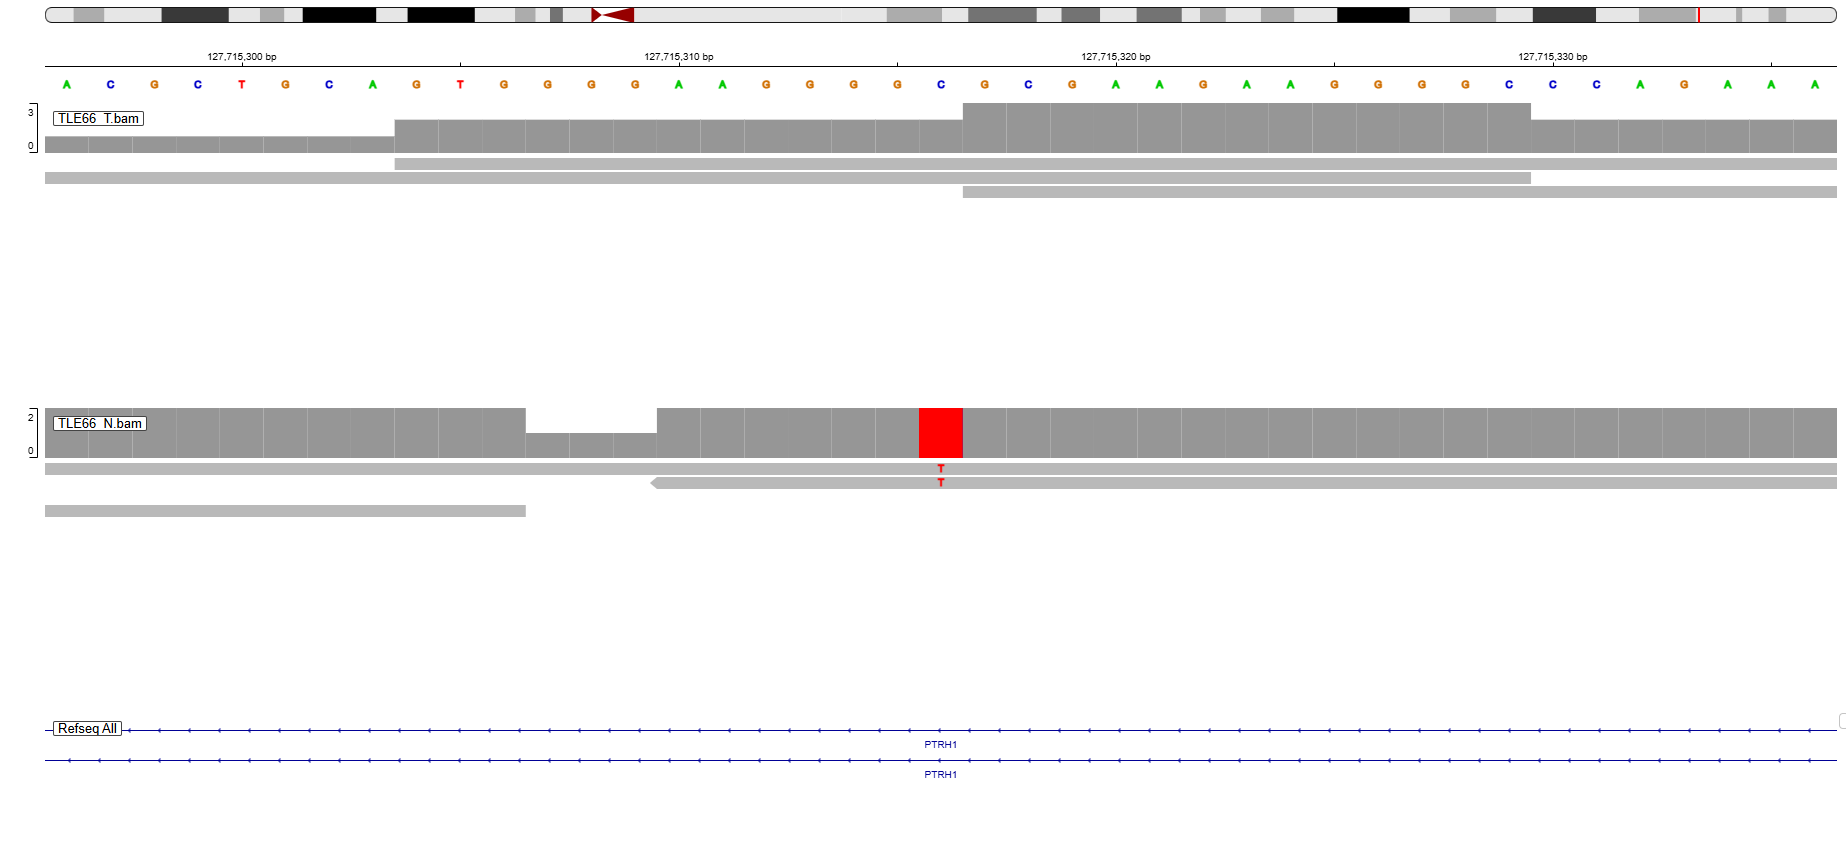

## Snp Annotation using SnpEff

In [38]:
# get help using:
snpEff || true

Error        :	Missing genomer_version parameter
Command line :	SnpEff  

snpEff version SnpEff 5.4a (build 2025-11-25 12:22), by Pablo Cingolani
Usage: snpEff [ann] [options] genome_version [input_file]


	variants_file                   : Default is STDIN



Options:
	-chr <string>                   : Prepend 'string' to chromosome name (e.g. 'chr1' instead of '1'). Only on TXT output.
	-classic                        : Use old style annotations instead of Sequence Ontology and Hgvs.
	-csvStats <file>                : Create CSV summary file.
	-download                       : Download reference genome if not available. Default: true
	-i <format>                     : Input format [ vcf, bed ]. Default: VCF.
	-fileList                       : Input actually contains a list of files to process.
	-o <format>                     : Output format [ vcf, gatk, bed, bedAnn ]. Default: VCF.
	-s , -stats, -htmlStats         : Create HTML summary file.  Default is 'snpEff_summary.html'
	-noSta

In [41]:
# sorry this is ugly - but to run snpEff - we need more memory
# I'm sure there is a more elegant way - but I could not find it..

SNPEFF_JAR="/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/share/snpeff-5.4.0a-0/snpEff.jar"

java -Xmx3400m -jar ${SNPEFF_JAR} eff hg19 -dataDir /staging/leuven/stg_00079/teaching/snpeff_db \
        clean_snps.vcf > annotated_snps.vcf



NEW VERSION!
	There is a new SnpEff version available: 
		Version      : 5.4C
		Release date : 2026-02-23
		Download URL : https://snpeff-public.s3.amazonaws.com/versions/snpEff_latest_core.zip



<div style="background-color: khaki; padding: 10px;">

## snpEff Quality control

* Do you have annotations in the records? Show one HIGH impact one? 
* Can you think of other (simple) controls for a snpEff annotated vcf file?

</div>


In [44]:
head -20 snpEff_genes.txt

# The following table is formatted as tab separated values. 
#GeneName	GeneId	TranscriptId	BioType	variants_impact_HIGH	variants_impact_LOW	variants_impact_MODERATE	variants_impact_MODIFIER	variants_effect_3_prime_UTR_variant	variants_effect_5_prime_UTR_premature_start_codon_gain_variant	variants_effect_5_prime_UTR_variant	variants_effect_downstream_gene_variant	variants_effect_frameshift_variant	variants_effect_intron_variant	variants_effect_missense_variant	variants_effect_non_coding_transcript_exon_variant	variants_effect_splice_acceptor_variant	variants_effect_splice_donor_variant	variants_effect_splice_region_variant	variants_effect_start_retained_variant	variants_effect_stop_gained	variants_effect_synonymous_variant	variants_effect_upstream_gene_variant
ABL1	ABL1	NM_005157.6	protein_coding	1	0	0	27	0	0	0	2	0	23	0	0	0	0	0	0	1	0	2
ABL1	ABL1	NM_007313.2	protein_coding	1	1	0	98	0	1	1	2	0	87	0	0	0	0	0	0	1	0	8
ABO	ABO	NM_020469.3	protein_coding	0	0	0	25	1	0	0	1	0	12	0	0	0	0	0	0	0	0	11


In [49]:
#Hight impact
awk '$5>0 {print $1, $2, $3, "HIGH impact variants:", $5}' snpEff_genes.txt | head 

# The following HIGH impact variants: is
#GeneName GeneId TranscriptId HIGH impact variants: variants_impact_HIGH
ABL1 ABL1 NM_005157.6 HIGH impact variants: 1
ABL1 ABL1 NM_007313.2 HIGH impact variants: 1
AK8 AK8 NM_001317959.2 HIGH impact variants: 1
AK8 AK8 NM_001371771.1 HIGH impact variants: 1
AK8 AK8 NM_001371772.1 HIGH impact variants: 1
AK8 AK8 NM_152572.3 HIGH impact variants: 1
CEL CEL NM_001807.5 HIGH impact variants: 1
CFAP157 CFAP157 NR_145961.2 HIGH impact variants: 1


Variants are annotated in the INFO field (ANN). A HIGH impact example is ABL1, transcript NM_005157.6, 1 HIGH impact variant. Simple QC checks: confirm annotations exist, check that HIGH/MODERATE/LOW/MODIFIER counts are reasonable, and that predicted effects match expected variant types.